# NYT Data: Character Length Analysis & Filtering Recommendation

NYT articles are **abstracts/snippets** (not full article text).  
Many entries may be too short to be useful for mid-training data.

This notebook:
1. Loads all NYT parquet files (1851-2017)
2. Computes character-length statistics on `combined_text`
3. Shows the distribution & percentiles
4. Displays example articles at various length tiers
5. Recommends a minimum character-length cutoff for filtering

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent.parent.parent
NYT_DIR = PROJECT_ROOT / "Data" / "additional_data" / "news_archives" / "NYT"

print(f"NYT directory: {NYT_DIR}")
print(f"Exists: {NYT_DIR.exists()}")
nyt_files = sorted(NYT_DIR.glob("nyt_*.parquet"))
print(f"Parquet files found: {len(nyt_files)} (years {nyt_files[0].stem.split('_')[1]}-{nyt_files[-1].stem.split('_')[1]})")

NYT directory: C:\Users\danielyoon\Dropbox\hist_LLM\Data\additional_data\news_archives\NYT
Exists: True
Parquet files found: 167 (years 1851-2017)


## 1. Load all NYT data and compute character lengths

We load `combined_text` and `word_count` from every year file.

In [2]:
# Load lightweight columns from all years
frames = []
for f in nyt_files:
    year = int(f.stem.split('_')[1])
    df = pd.read_parquet(f, columns=["combined_text", "word_count", "type_of_material", "document_type"])
    df["year"] = year
    frames.append(df)

nyt = pd.concat(frames, ignore_index=True)
print(f"Total NYT records: {len(nyt):,}")

# Compute character length
nyt["char_len"] = nyt["combined_text"].fillna("").str.len()

# Drop rows with empty/null text
empty_mask = nyt["combined_text"].isna() | (nyt["char_len"] == 0)
print(f"Empty/null combined_text: {empty_mask.sum():,} ({empty_mask.mean()*100:.2f}%)")
nyt = nyt[~empty_mask].copy()
print(f"After removing empty: {len(nyt):,}")

Total NYT records: 15,035,424
Empty/null combined_text: 169 (0.00%)
After removing empty: 15,035,255


## 2. Overall character-length distribution

In [3]:
cl = nyt["char_len"]

print("Character-length statistics (combined_text):")
print(f"  Count:  {len(cl):,}")
print(f"  Mean:   {cl.mean():,.0f}")
print(f"  Median: {cl.median():,.0f}")
print(f"  Std:    {cl.std():,.0f}")
print(f"  Min:    {cl.min():,}")
print(f"  Max:    {cl.max():,}")
print()

print("Percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = cl.quantile(p / 100)
    print(f"  p{p:>2}: {val:>8,.0f} chars")

print()
print("Word-count (from NYT metadata) statistics:")
wc = nyt["word_count"]
print(f"  Mean:   {wc.mean():,.0f}")
print(f"  Median: {wc.median():,.0f}")
for p in [10, 25, 50, 75, 90]:
    print(f"  p{p:>2}: {wc.quantile(p/100):>8,.0f} words")

Character-length statistics (combined_text):
  Count:  15,035,255
  Mean:   309
  Median: 256
  Std:    487
  Min:    1
  Max:    109,945

Percentiles:
  p 1:       13 chars
  p 5:       21 chars
  p10:       27 chars
  p25:       78 chars
  p50:      256 chars
  p75:      442 chars
  p90:      624 chars
  p95:      800 chars
  p99:    1,275 chars

Word-count (from NYT metadata) statistics:
  Mean:   469
  Median: 256
  p10:       56 words
  p25:      110 words
  p50:      256 words
  p75:      637 words
  p90:    1,061 words


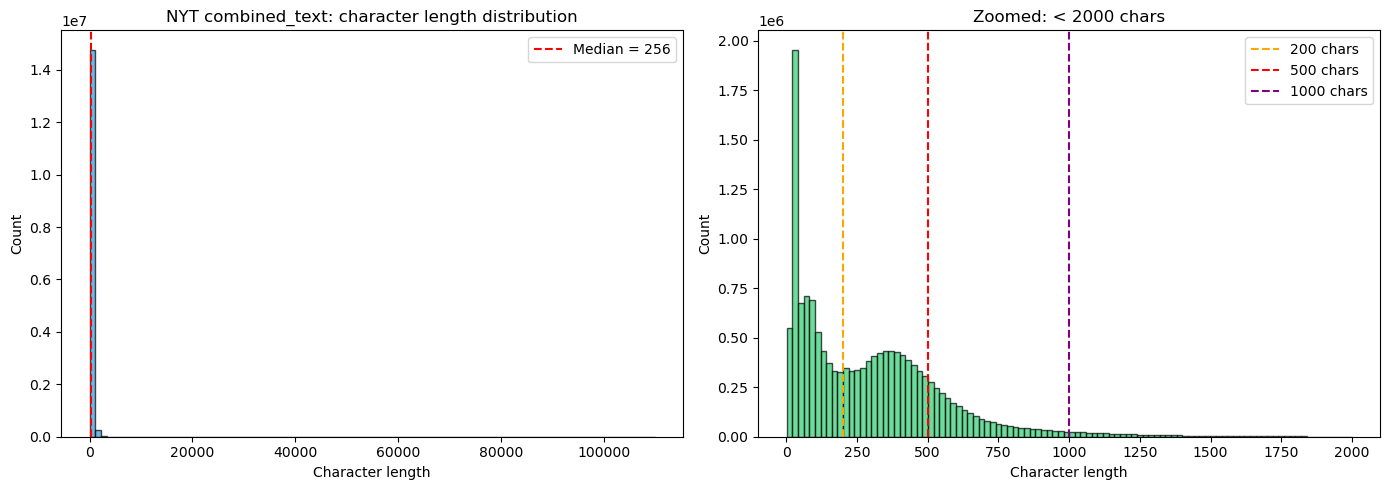

In [4]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: full histogram
    axes[0].hist(cl, bins=100, color="#3498db", edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Character length")
    axes[0].set_ylabel("Count")
    axes[0].set_title("NYT combined_text: character length distribution")
    axes[0].axvline(cl.median(), color="red", ls="--", lw=1.5, label=f"Median = {cl.median():.0f}")
    axes[0].legend()

    # Right: zoomed in to < 2000 chars (where most data is)
    sub = cl[cl < 2000]
    axes[1].hist(sub, bins=100, color="#2ecc71", edgecolor="black", alpha=0.7)
    axes[1].set_xlabel("Character length")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Zoomed: < 2000 chars")
    for cutoff, color, label in [(200, "orange", "200"), (500, "red", "500"), (1000, "purple", "1000")]:
        axes[1].axvline(cutoff, color=color, ls="--", lw=1.5, label=f"{label} chars")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available")

## 3. Cumulative retention at various cutoffs

How many articles survive each minimum character-length threshold?

In [5]:
total = len(nyt)
cutoffs = [0, 50, 100, 150, 200, 250, 300, 400, 500, 600, 750, 1000, 1500, 2000, 3000]

print(f"{'Min chars':>10}  {'Remaining':>12}  {'% kept':>8}  {'% dropped':>10}")
print("-" * 50)
for c in cutoffs:
    n = (cl >= c).sum()
    print(f"{c:>10,}  {n:>12,}  {n/total*100:>7.1f}%  {(1 - n/total)*100:>9.1f}%")

 Min chars     Remaining    % kept   % dropped
--------------------------------------------------
         0    15,035,255    100.0%        0.0%
        50    12,212,479     81.2%       18.8%
       100    10,476,452     69.7%       30.3%
       150     9,318,108     62.0%       38.0%
       200     8,479,693     56.4%       43.6%
       250     7,635,093     50.8%       49.2%
       300     6,737,267     44.8%       55.2%
       400     4,613,486     30.7%       69.3%
       500     2,805,408     18.7%       81.3%
       600     1,687,842     11.2%       88.8%
       750       898,667      6.0%       94.0%
     1,000       380,247      2.5%       97.5%
     1,500        77,581      0.5%       99.5%
     2,000        32,592      0.2%       99.8%
     3,000        16,909      0.1%       99.9%


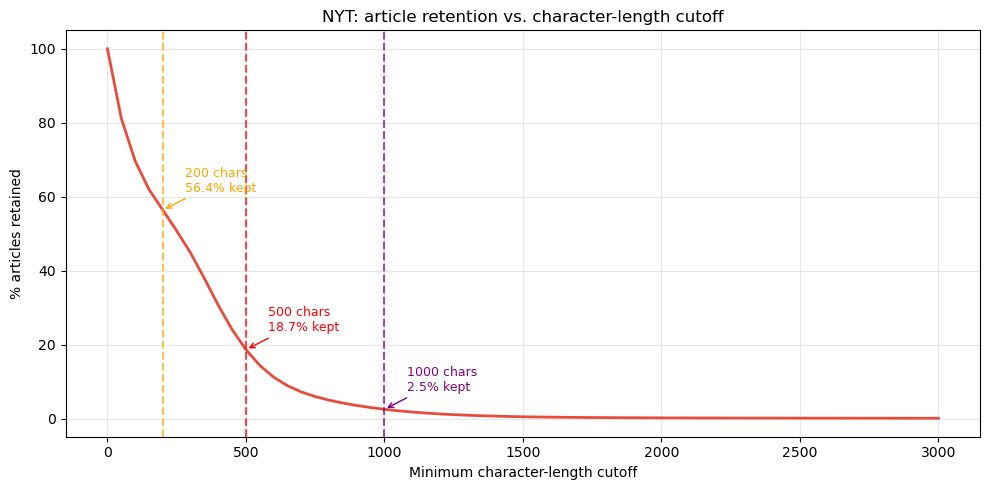

In [6]:
try:
    import matplotlib.pyplot as plt

    test_cutoffs = list(range(0, 3001, 50))
    pct_kept = [(cl >= c).mean() * 100 for c in test_cutoffs]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(test_cutoffs, pct_kept, color="#e74c3c", lw=2)
    ax.set_xlabel("Minimum character-length cutoff")
    ax.set_ylabel("% articles retained")
    ax.set_title("NYT: article retention vs. character-length cutoff")
    ax.grid(True, alpha=0.3)

    # Mark candidate cutoffs
    for c, color in [(200, "orange"), (500, "red"), (1000, "purple")]:
        pct = (cl >= c).mean() * 100
        ax.axvline(c, color=color, ls="--", alpha=0.7)
        ax.annotate(f"{c} chars\n{pct:.1f}% kept", xy=(c, pct),
                    xytext=(c + 80, pct + 5), fontsize=9,
                    arrowprops=dict(arrowstyle="->", color=color), color=color)

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available")

## 4. Breakdown by article type

Some article types (e.g., obituaries, brief items) may be inherently short.  
Let's see length distributions by `type_of_material` and `document_type`.

In [7]:
# By type_of_material
type_stats = nyt.groupby("type_of_material").agg(
    count=("char_len", "size"),
    mean_len=("char_len", "mean"),
    median_len=("char_len", "median"),
    p25=("char_len", lambda x: x.quantile(0.25)),
    p75=("char_len", lambda x: x.quantile(0.75)),
).sort_values("count", ascending=False)

print("Character-length by type_of_material (top 15):")
print(f"{'type_of_material':<30} {'Count':>10} {'Mean':>8} {'Median':>8} {'p25':>8} {'p75':>8}")
print("-" * 82)
for typ, row in type_stats.head(15).iterrows():
    label = str(typ)[:30] if typ else "(None)"
    print(f"{label:<30} {int(row['count']):>10,} {row['mean_len']:>8.0f} {row['median_len']:>8.0f} {row['p25']:>8.0f} {row['p75']:>8.0f}")

Character-length by type_of_material (top 15):
type_of_material                    Count     Mean   Median      p25      p75
----------------------------------------------------------------------------------
Article                         9,016,661      250      219       69      400
News                            2,083,972      525      456      226      721
Front Page                        795,290      334      317       81      503
Editorial                         445,412      310      305       98      412
Obituary                          413,347       80       38       27       91
Letter                            406,461      307      286       70      452
Blog                              372,923      362      305      186      496
Review                            298,503      493      404      216      638
Marriage Announcement             236,906       61       38       29       85
Paid Death Notice                 215,138      658      470      295      765
Statistics  

In [8]:
# By era (decade)
nyt["decade"] = (nyt["year"] // 10) * 10
decade_stats = nyt.groupby("decade").agg(
    count=("char_len", "size"),
    mean_len=("char_len", "mean"),
    median_len=("char_len", "median"),
).sort_index()

print("Character-length by decade:")
print(f"{'Decade':<10} {'Count':>12} {'Mean len':>10} {'Median len':>10}")
print("-" * 46)
for decade, row in decade_stats.iterrows():
    print(f"{decade:<10} {int(row['count']):>12,} {row['mean_len']:>10.0f} {row['median_len']:>10.0f}")

Character-length by decade:
Decade            Count   Mean len Median len
----------------------------------------------
1850            152,214        230        272
1860            232,455        229        208
1870            381,571        182         80
1880            547,556        221        239
1890            557,355        220        102
1900            622,749        223        117
1910            710,903        252        169
1920          1,185,002        255        167
1930          1,627,683        259        226
1940          1,489,730        223        134
1950          1,502,674        205        133
1960          1,276,106        211        180
1970            915,663        402        358
1980          1,014,628        440        364
1990            822,298        616        530
2000          1,124,745        615        498
2010            871,923        318        229


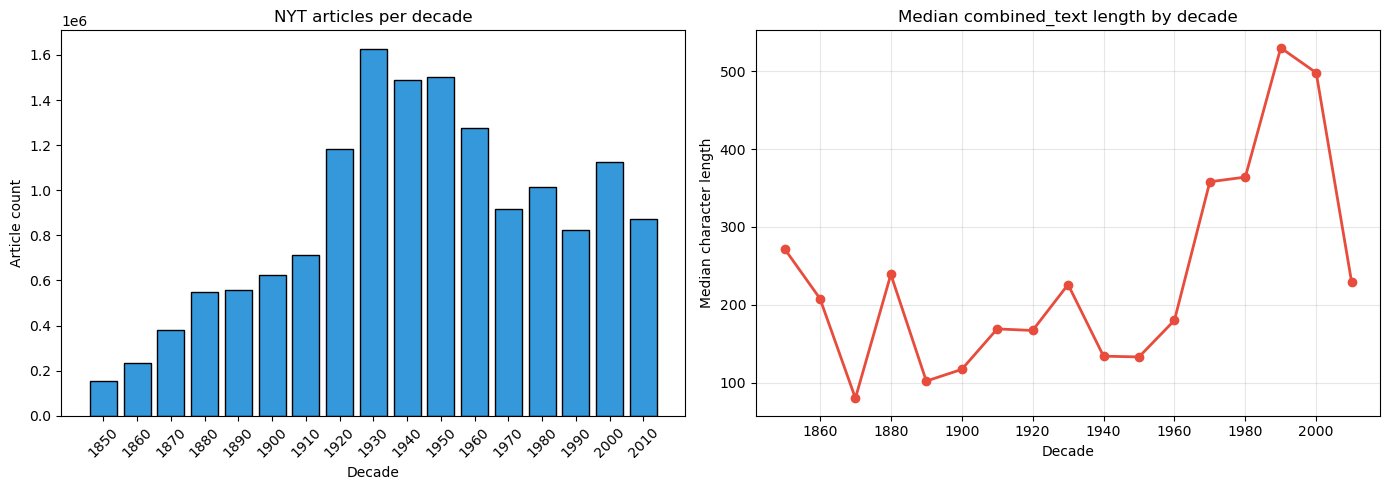

In [9]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Article count by decade
    axes[0].bar(decade_stats.index.astype(str), decade_stats["count"], color="#3498db", edgecolor="black")
    axes[0].set_xlabel("Decade")
    axes[0].set_ylabel("Article count")
    axes[0].set_title("NYT articles per decade")
    axes[0].tick_params(axis='x', rotation=45)

    # Median length by decade
    axes[1].plot(decade_stats.index, decade_stats["median_len"], "o-", color="#e74c3c", lw=2)
    axes[1].set_xlabel("Decade")
    axes[1].set_ylabel("Median character length")
    axes[1].set_title("Median combined_text length by decade")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available")

## 5. Example articles at various length tiers

Let's look at actual text to judge quality at different lengths.

In [10]:
def show_examples(df, tier_label, n=3):
    """Show n random examples from a dataframe slice."""
    sample = df.sample(n=min(n, len(df)), random_state=42)
    print(f"\n{'='*80}")
    print(f"  TIER: {tier_label}  ({len(df):,} articles in this range)")
    print(f"{'='*80}")
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        text = row["combined_text"]
        preview = text[:2000] + ("..." if len(text) > 2000 else "")
        print(f"\n--- Example {i} | Year: {row['year']} | {row['char_len']:,} chars | "
              f"word_count: {row['word_count']} | type: {row['type_of_material']} ---")
        print(preview)

# Very short (< 100 chars)
show_examples(nyt[nyt["char_len"] < 100], "< 100 chars (very short)")

# Short (100-200 chars)
show_examples(nyt[(nyt["char_len"] >= 100) & (nyt["char_len"] < 200)], "100-200 chars")

# Medium-short (200-500 chars)
show_examples(nyt[(nyt["char_len"] >= 200) & (nyt["char_len"] < 500)], "200-500 chars")


  TIER: < 100 chars (very short)  (4,558,803 articles in this range)

--- Example 1 | Year: 1894 | 24 chars | word_count: 239.0 | type: Article ---
FINANCIAL ANNOUNCEMENTS.

--- Example 2 | Year: 1898 | 14 chars | word_count: 101.0 | type: Article ---
The Spaniards.

--- Example 3 | Year: 1945 | 51 chars | word_count: 257.0 | type: Article ---
Advertising News; Accounts Personnel Note

Ad plans

  TIER: 100-200 chars  (1,996,759 articles in this range)

--- Example 1 | Year: 1942 | 101 chars | word_count: 129.0 | type: Article ---
BOWDOIN SINGERS HEARD; Glee Club of 60 Gives Its First Concert in Town Hall

Glee Club concert, N Y C

--- Example 2 | Year: 1936 | 142 chars | word_count: 141.0 | type: Marriage Announcement ---
MRS, SALTONSTALL ENGAGED TO1VIIRRN; Boston Woman to Be Bride of Dr. Joel E. Goldthwait, an Orthopedic Surgeon.

Engaged to Mrs F S Saltonstall

--- Example 3 | Year: 1980 | 181 chars | word_count: 297.0 | type: Article ---
Home Beat; Two Designing Brothers

THEY'VE 

In [11]:
# Medium (500-1000 chars)
show_examples(nyt[(nyt["char_len"] >= 500) & (nyt["char_len"] < 1000)], "500-1000 chars")

# Long (1000-2000 chars)
show_examples(nyt[(nyt["char_len"] >= 1000) & (nyt["char_len"] < 2000)], "1000-2000 chars")

# Very long (2000+ chars)
show_examples(nyt[nyt["char_len"] >= 2000], "2000+ chars")


  TIER: 500-1000 chars  (2,425,161 articles in this range)

--- Example 1 | Year: 1976 | 861 chars | word_count: 649.0 | type: Article ---
Parliament Bypassed by New Wage Pact

agreement between Brit Govt and leaders of major unions on new wage policy was made without even perfunctory consultation with House of Commons; in mo of secret negotiations. Prime Min James Callaghan and Chancellor of Exchequer Denis Healey, acting for Govt, and Lionel Murray, head of Trades Union Cong, and Jack Jones, head of Transport and General Workers Union, agreed to limit avg increases in weekly wages to 4.5%, with minimum raise of $4.60 for lower-paid workers and maximum of $7.32 for highest paid; agreement is voluntary; Conservative spokesman Sir Geoffrey Howe comments (M)

LONDON, May 6 There is a story told about a visitor to Dublin who loses his way and asks a local resident how to find a certain street. "Well," says the Irishman after a thoughtful pause, "to begin with, I wouldn't start from here.

## 6. Deep dive: what makes up the long articles?

The `combined_text` concatenates headline + abstract + lead_paragraph.  
Let's check which component contributes the most length.

In [12]:
# Reload a sample year with all text fields to check component contribution
sample_years = [1900, 1950, 2000]
component_frames = []

for y in sample_years:
    p = NYT_DIR / f"nyt_{y}.parquet"
    if p.exists():
        df = pd.read_parquet(p, columns=["headline_main", "abstract", "lead_paragraph", "snippet", "combined_text"])
        df["year"] = y
        component_frames.append(df)

comp = pd.concat(component_frames, ignore_index=True)

for col in ["headline_main", "abstract", "lead_paragraph", "snippet", "combined_text"]:
    lengths = comp[col].fillna("").str.len()
    non_empty = (lengths > 0).sum()
    print(f"{col:<20}  non-empty: {non_empty:>8,}/{len(comp):,} ({non_empty/len(comp)*100:.1f}%)  "
          f"mean_len: {lengths[lengths > 0].mean():>6.0f}  median: {lengths[lengths > 0].median():>6.0f}")

headline_main         non-empty:  325,748/325,748 (100.0%)  mean_len:     60  median:     40
abstract              non-empty:  173,210/325,748 (53.2%)  mean_len:    130  median:     78
lead_paragraph        non-empty:  183,163/325,748 (56.2%)  mean_len:    418  median:    313
snippet               non-empty:  233,438/325,748 (71.7%)  mean_len:    192  median:    250
combined_text         non-empty:  325,748/325,748 (100.0%)  mean_len:    366  median:    279


## 7. Recommendation

Based on the analysis above, this cell summarizes the recommended cutoff.

In [13]:
# Summary: compute counts for candidate cutoffs
print("="*70)
print("  FILTERING RECOMMENDATION SUMMARY")
print("="*70)
print()
print(f"Total NYT articles (non-empty): {len(nyt):,}")
print(f"Median character length: {cl.median():.0f}")
print(f"Mean character length:   {cl.mean():.0f}")
print()

candidates = [
    (200, "Removes very short items (headlines-only, brief notices)"),
    (300, "Ensures at least a headline + meaningful abstract"),
    (500, "Keeps articles with substantive lead paragraph"),
    (1000, "Only keeps articles with full headline + abstract + lead paragraph"),
]

print(f"{'Cutoff':>8}  {'Kept':>12}  {'% of total':>10}  Description")
print("-" * 80)
for cutoff, desc in candidates:
    n = (cl >= cutoff).sum()
    print(f"{cutoff:>8}  {n:>12,}  {n/len(nyt)*100:>9.1f}%  {desc}")

print()
print("RECOMMENDATION:")
print("  A cutoff of ~500 characters is a good balance:")
print("  - Removes trivially short entries (marriage notices, bare headlines)")
print("  - Retains articles with enough substance for mid-training")
print("  - Adjust up to 1000 if you want only the richest entries")
print()
print("  For reference, 500 chars ~ 80-100 words of actual content.")
print("  The retained articles will include headline + meaningful abstract/lead paragraph.")

  FILTERING RECOMMENDATION SUMMARY

Total NYT articles (non-empty): 15,035,255
Median character length: 256
Mean character length:   309

  Cutoff          Kept  % of total  Description
--------------------------------------------------------------------------------
     200     8,479,693       56.4%  Removes very short items (headlines-only, brief notices)
     300     6,737,267       44.8%  Ensures at least a headline + meaningful abstract
     500     2,805,408       18.7%  Keeps articles with substantive lead paragraph
    1000       380,247        2.5%  Only keeps articles with full headline + abstract + lead paragraph

RECOMMENDATION:
  A cutoff of ~500 characters is a good balance:
  - Removes trivially short entries (marriage notices, bare headlines)
  - Retains articles with enough substance for mid-training
  - Adjust up to 1000 if you want only the richest entries

  For reference, 500 chars ~ 80-100 words of actual content.
  The retained articles will include headline + me